Problem Statement:

Porter is India's Largest Marketplace for Intra-City Logistics. Leader in the country's $40 billion intra-city logistics market, Porter strives to improve the lives of 1,50,000+ driver-partners by providing them with consistent earning & independence. Currently, the company has serviced 5+ million customers

Porter works with a wide range of restaurants for delivering their items directly to the people.

Porter has a number of delivery partners available for delivering the food, from various restaurants and wants to get an estimated delivery time that it can provide the customers on the basis of what they are ordering, from where and also the delivery partners.

This dataset has the required data to train a regression model that will do the delivery time estimation, based on all those features

Data Dictionary

market_id : integer id for the market where the restaurant lies

created_at : the timestamp at which the order was placed

actual_delivery_time : the timestamp when the order was delivered

store_id : encoded id for different stores

order_protocol : integer code value for order protocol(how the order was placed ie: through porter, call to restaurant, prebooked, third part etc)

total_items subtotal : final price of the order

num_distinct_items : the number of distinct items in the order

min_item_price : price of the cheapest item in the order

max_item_price : price of the costliest item in order

total_onshift_partners : number of delivery partners on duty at the time order was placed

total_busy_partners : number of delivery partners attending to other tasks

total_outstanding_orders : total number of orders to be fulfilled at the moment

estimated_store_to_consumer_driving_duration : approximate travel time from restaurant to customer

Importing Necessary  Data and  libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data= pd.read_csv('dataset.csv')

In [ ]:
df= pd.DataFrame(data)
df

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197423,1.0,2015-02-17 00:19:41,2015-02-17 01:24:48,a914ecef9c12ffdb9bede64bb703d877,fast,4.0,3,1389,3,345,649,17.0,17.0,23.0
197424,1.0,2015-02-13 00:01:59,2015-02-13 00:58:22,a914ecef9c12ffdb9bede64bb703d877,fast,4.0,6,3010,4,405,825,12.0,11.0,14.0
197425,1.0,2015-01-24 04:46:08,2015-01-24 05:36:16,a914ecef9c12ffdb9bede64bb703d877,fast,4.0,5,1836,3,300,399,39.0,41.0,40.0
197426,1.0,2015-02-01 18:18:15,2015-02-01 19:23:22,c81e155d85dae5430a8cee6f2242e82c,sandwich,1.0,1,1175,1,535,535,7.0,7.0,12.0


Understanding the Structure of the data

In [ ]:
df.shape

(197428, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

In [ ]:
df.isna().sum()

,0
market_id,987
created_at,0
actual_delivery_time,7
store_id,0
store_primary_category,4760
order_protocol,995
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0


In [ ]:
df.describe()

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


In [ ]:
df['created_at']= pd.to_datetime(df['created_at'])
df['actual_delivery_time']= pd.to_datetime(df['actual_delivery_time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 176248 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   market_id                 176248 non-null  float64       
 1   created_at                176248 non-null  datetime64[ns]
 2   actual_delivery_time      176248 non-null  datetime64[ns]
 3   store_id                  176248 non-null  object        
 4   store_primary_category    176248 non-null  object        
 5   order_protocol            176248 non-null  float64       
 6   total_items               176248 non-null  int64         
 7   subtotal                  176248 non-null  int64         
 8   num_distinct_items        176248 non-null  int64         
 9   min_item_price            176248 non-null  int64         
 10  max_item_price            176248 non-null  int64         
 11  total_onshift_partners    176248 non-null  float64       
 12  total_b

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.dropna(inplace=True)
df.isna().sum()

,0
market_id,0
created_at,0
actual_delivery_time,0
store_id,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0


In [ ]:
df.shape

(176248, 14)

In [ ]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
8,2.0,2015-02-16 00:11:35,2015-02-16 00:38:01,f0ade77b43923b38237db569b016ba25,indian,3.0,4,4771,3,820,1604,8.0,6.0,18.0
14,1.0,2015-02-12 03:36:46,2015-02-12 04:14:39,ef1e491a766ce3127556063d49bc2f98,italian,1.0,1,1525,1,1525,1525,5.0,6.0,8.0
15,1.0,2015-01-27 02:12:36,2015-01-27 03:02:24,ef1e491a766ce3127556063d49bc2f98,italian,1.0,2,3620,2,1425,2195,5.0,5.0,7.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 176248 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 176248 non-null  float64
 1   created_at                176248 non-null  object 
 2   actual_delivery_time      176248 non-null  object 
 3   store_id                  176248 non-null  object 
 4   store_primary_category    176248 non-null  object 
 5   order_protocol            176248 non-null  float64
 6   total_items               176248 non-null  int64  
 7   subtotal                  176248 non-null  int64  
 8   num_distinct_items        176248 non-null  int64  
 9   min_item_price            176248 non-null  int64  
 10  max_item_price            176248 non-null  int64  
 11  total_onshift_partners    176248 non-null  float64
 12  total_busy_partners       176248 non-null  float64
 13  total_outstanding_orders  176248 non-null  float6

In [ ]:
df['store_primary_category'].value_counts()

,count
store_primary_category,
american,18223
pizza,15782
mexican,15624
burger,9936
sandwich,9046
...,...
african,10
lebanese,9
belgian,2


In [ ]:
# convert the store_primary_category to a category type and encode it
df['store_primary_category']= df['store_primary_category'].astype('category')
df['store_primary_category']= df['store_primary_category'].cat.codes
df['store_id']= df['store_id'].astype('category')
df['store_id']= df['store_id'].cat.codes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 176248 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   market_id                 176248 non-null  float64       
 1   created_at                176248 non-null  datetime64[ns]
 2   actual_delivery_time      176248 non-null  datetime64[ns]
 3   store_id                  176248 non-null  int16         
 4   store_primary_category    176248 non-null  int8          
 5   order_protocol            176248 non-null  float64       
 6   total_items               176248 non-null  int64         
 7   subtotal                  176248 non-null  int64         
 8   num_distinct_items        176248 non-null  int64         
 9   min_item_price            176248 non-null  int64         
 10  max_item_price            176248 non-null  int64         
 11  total_onshift_partners    176248 non-null  float64       
 12  total_b

In [ ]:

df['created_hour']= df['created_at'].dt.hour


In [ ]:
df['created_at']

,created_at
0,2015-02-06 22:24:17
1,2015-02-10 21:49:25
8,2015-02-16 00:11:35
14,2015-02-12 03:36:46
15,2015-01-27 02:12:36
...,...
197423,2015-02-17 00:19:41
197424,2015-02-13 00:01:59
197425,2015-01-24 04:46:08
197426,2015-02-01 18:18:15


In [ ]:
# create a new column for the delivery time taken in minutes
df['delivery_time']= df['actual_delivery_time']- df['created_at']
df['delivery_time']= df['delivery_time'].dt.total_seconds()/60
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_hour,delivery_time
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,4959,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,22,62.983333
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5315,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,21,67.066667
8,2.0,2015-02-16 00:11:35,2015-02-16 00:38:01,5315,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,0,26.433333
14,1.0,2015-02-12 03:36:46,2015-02-12 04:14:39,5279,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,3,37.883333
15,1.0,2015-01-27 02:12:36,2015-01-27 03:02:24,5279,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,2,49.800000


In [ ]:
df['created_hour']= df['created_at'].dt.hour

In [ ]:
df['created_day']= df['created_at'].dt.day

In [ ]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_hour,delivery_time,created_day
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,4959,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,22,62.983333,6
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5315,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,21,67.066667,10
8,2.0,2015-02-16 00:11:35,2015-02-16 00:38:01,5315,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,0,26.433333,16
14,1.0,2015-02-12 03:36:46,2015-02-12 04:14:39,5279,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,3,37.883333,12
15,1.0,2015-01-27 02:12:36,2015-01-27 03:02:24,5279,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,2,49.800000,27


In [ ]:
df['created_month']= df['created_at'].dt.month
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_hour,delivery_time,created_day,created_month
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,4959,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,22,62.983333,6,2
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5315,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,21,67.066667,10,2
8,2.0,2015-02-16 00:11:35,2015-02-16 00:38:01,5315,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,0,26.433333,16,2
14,1.0,2015-02-12 03:36:46,2015-02-12 04:14:39,5279,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,3,37.883333,12,2
15,1.0,2015-01-27 02:12:36,2015-01-27 03:02:24,5279,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,2,49.800000,27,1


In [ ]:
df.drop(['created_at','actual_delivery_time'], axis=1, inplace=True)
df.head()

,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_hour,delivery_time,created_day,created_month
0,1.0,4959,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,22,62.983333,6,2
1,2.0,5315,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,21,67.066667,10,2
8,2.0,5315,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,0,26.433333,16,2
14,1.0,5279,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,3,37.883333,12,2
15,1.0,5279,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,2,49.800000,27,1


Visual Analysis

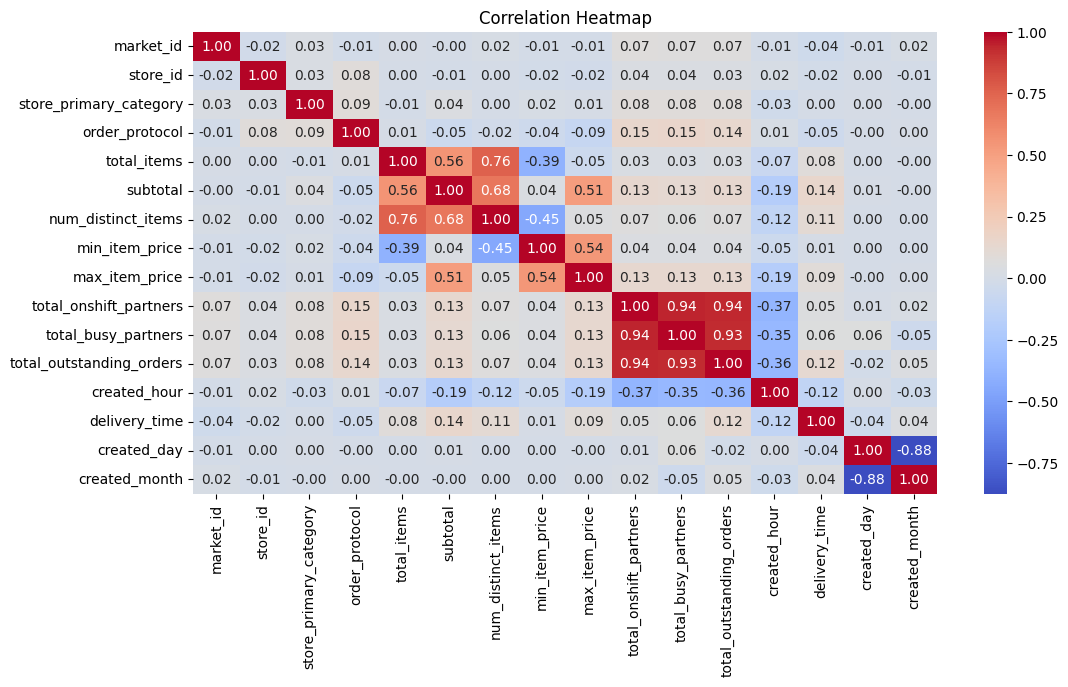

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
# Calculate correlation matrix
corr_matrix = df.corr()

# Plot heatmap with annotation
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


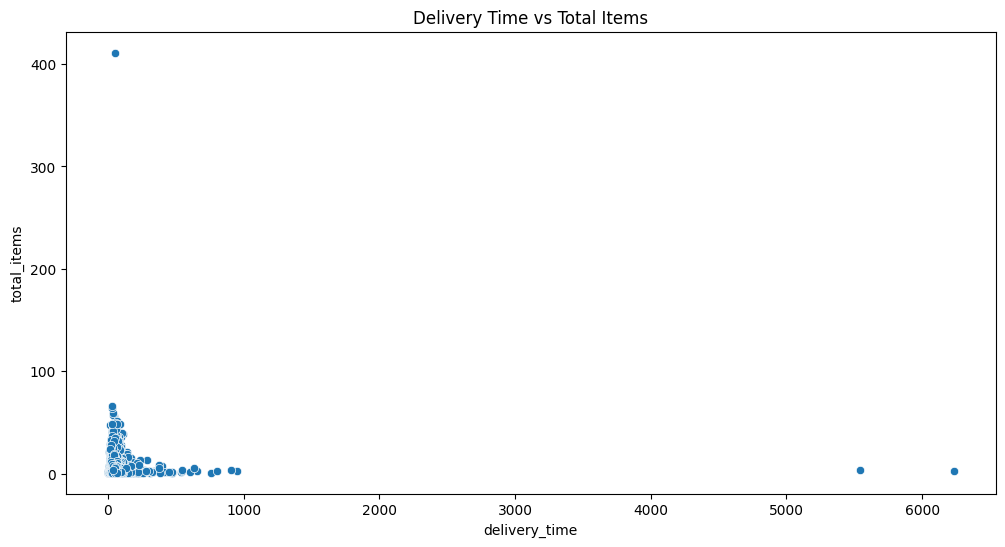

In [ ]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='delivery_time', y='total_items', data=df)
plt.title('Delivery Time vs Total Items')
plt.show()

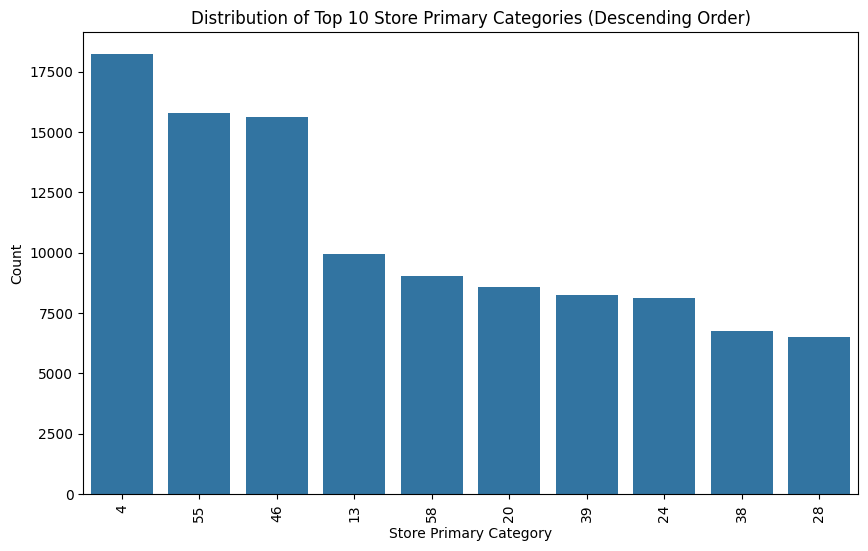

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted value counts as a DataFrame
sorted_counts = df['store_primary_category'].value_counts().sort_values(ascending=False).reset_index()[:10]
sorted_counts.columns = ['store_primary_category', 'count']

# Plot count plot using sorted DataFrame
plt.figure(figsize=(10, 6))
sns.barplot(data=sorted_counts, x='store_primary_category', y='count', order=sorted_counts['store_primary_category'])
plt.xticks(rotation=90)
plt.xlabel('Store Primary Category')
plt.ylabel('Count')
plt.title('Distribution of Top 10 Store Primary Categories (Descending Order)')
plt.show()


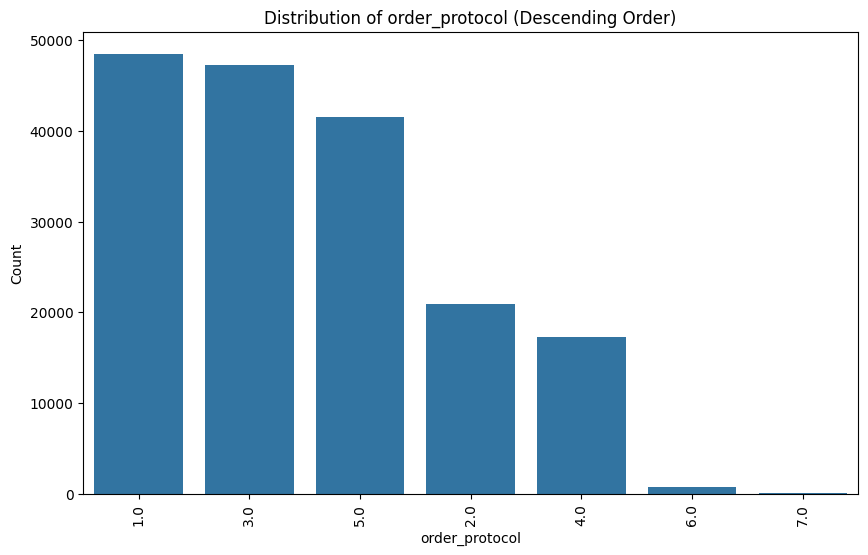

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted value counts as a DataFrame
sorted_counts = df['order_protocol'].value_counts().sort_values(ascending=False).reset_index()
sorted_counts.columns = ['order_protocol', 'count']

# Plot count plot using sorted DataFrame
plt.figure(figsize=(10, 6))
sns.barplot(data=sorted_counts, x='order_protocol', y='count', order=sorted_counts['order_protocol'])
plt.xticks(rotation=90)
plt.xlabel('order_protocol')
plt.ylabel('Count')
plt.title('Distribution of order_protocol (Descending Order)')
plt.show()


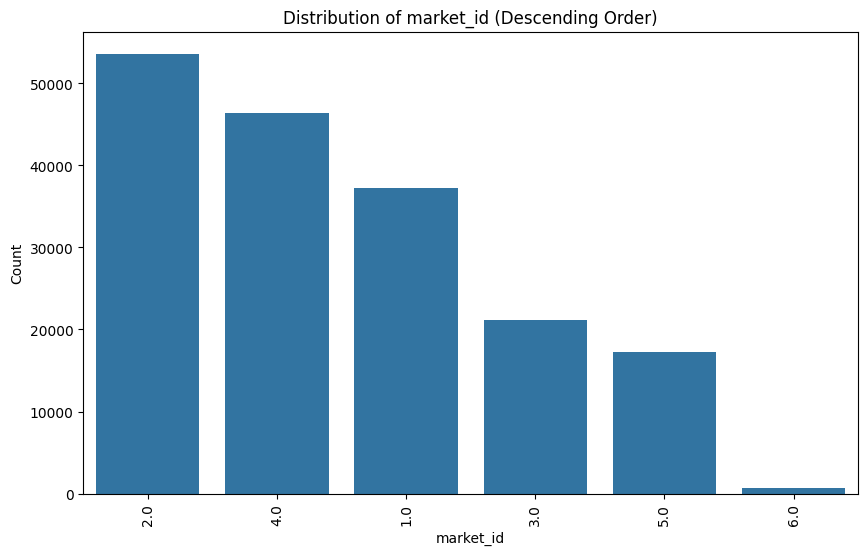

In [ ]:


# Get sorted value counts as a DataFrame
sorted_counts = df['market_id'].value_counts().sort_values(ascending=False).reset_index()
sorted_counts.columns = ['market_id', 'count']

# Plot count plot using sorted DataFrame
plt.figure(figsize=(10, 6))
sns.barplot(data=sorted_counts, x='market_id', y='count', order=sorted_counts['market_id'])
plt.xticks(rotation=90)
plt.xlabel('market_id')
plt.ylabel('Count')
plt.title('Distribution of market_id (Descending Order)')
plt.show()


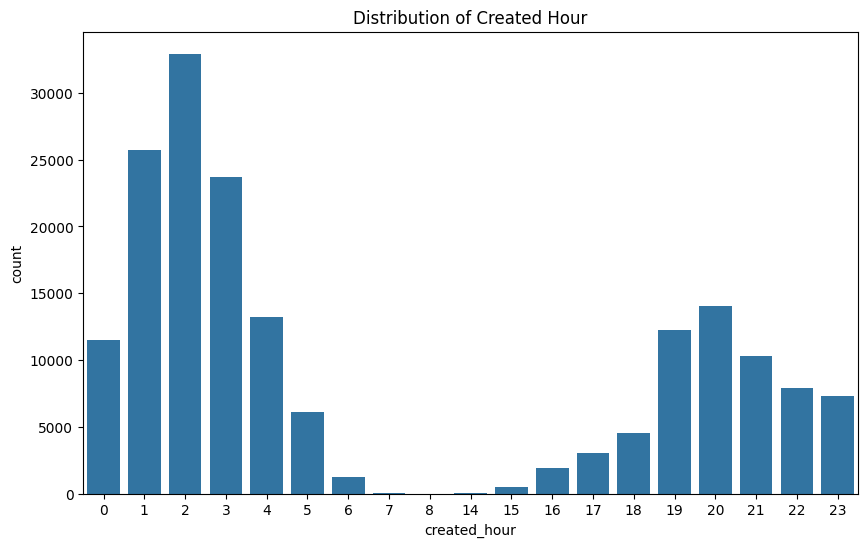

In [ ]:
# bar plot to show distribution of created hour
plt.figure(figsize=(10,6))
sns.countplot(x='created_hour', data=df)
plt.title('Distribution of Created Hour')
plt.show()

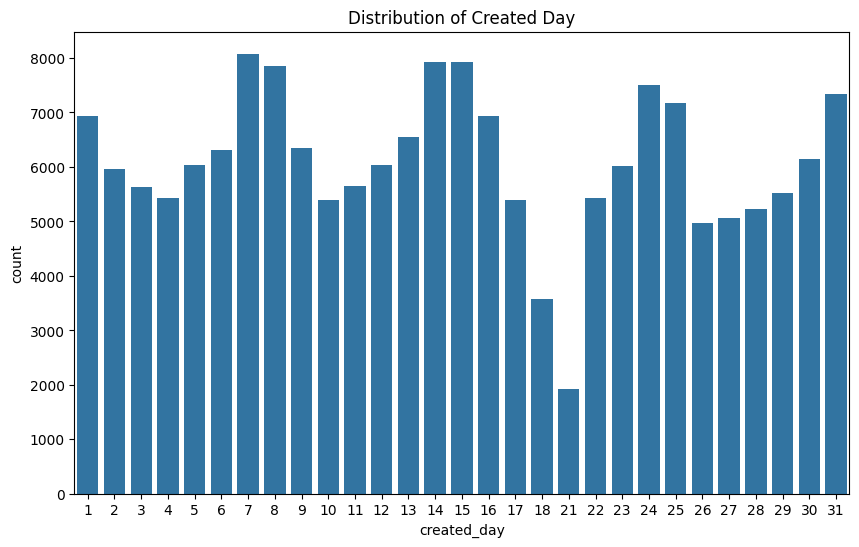

In [ ]:
# count plot to show distribution of created day, display the day of the day like sunday, monday, etc


plt.figure(figsize=(10,6))
sns.countplot(x='created_day', data=df)
plt.title('Distribution of Created Day')
plt.show()

Based on the visual analysis, here are some inferences:

1. **Correlation Heatmap**:
    - There is a strong positive correlation between `total_onshift_partners`, `total_busy_partners`, and `total_outstanding_orders`.
    - `subtotal` has a strong positive correlation with `total_items` and `num_distinct_items`.
    - `delivery_time` has a weak positive correlation with `total_items` and `subtotal`.

2. **Delivery Time vs Total Items**:
    - There is a slight positive trend indicating that as the number of total items increases, the delivery time also tends to increase.

3. **Distribution of Top 10 Store Primary Categories**:
    -

4. **Distribution of Order Protocol**:
    - The distribution of order protocols shows that certain protocols are used more frequently than others.

5. **Distribution of Market ID**:
    - The market IDs are not uniformly distributed, with some markets having significantly more orders than others.

6. **Distribution of Created Hour**:
    - The orders are distributed across different hours of the day, with some hours having higher order counts.

7. **Distribution of Created Day**:
    - The orders are distributed across different days, with some days having higher order counts.

These inferences can help in understanding the data better and can be used to make informed decisions for further analysis or model building.

In [ ]:
df.head()

,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_hour,delivery_time,created_day,created_month
0,1.0,4959,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,22,62.983333,6,2
1,2.0,5315,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,21,67.066667,10,2
8,2.0,5315,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,0,26.433333,16,2
14,1.0,5279,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,3,37.883333,12,2
15,1.0,5279,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,2,49.800000,27,1


In [ ]:
df.describe()

,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_hour,delivery_time,created_day,created_month
count,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000,176248.000000
mean,2.743747,2916.663826,35.891482,2.911687,3.204592,2696.498939,2.674589,684.937730,1159.886994,44.905276,41.845434,58.206800,8.493872,47.764210,15.397429,1.646589
std,1.330911,1666.523264,20.728572,1.512920,2.673899,1828.922584,1.625558,519.911425,560.784510,34.529394,32.154573,52.708344,8.681474,27.654861,9.234376,0.478030
min,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000,1.683333,1.000000,1.000000
25%,2.000000,1451.000000,18.000000,1.000000,2.000000,1408.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,2.000000,35.083333,7.000000,1.000000
50%,2.000000,2969.000000,38.000000,3.000000,3.000000,2221.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,3.000000,44.366667,14.000000,2.000000
75%,4.000000,4470.000000,55.000000,4.000000,4.000000,3407.000000,3.000000,942.000000,1395.000000,65.000000,62.000000,85.000000,19.000000,56.366667,24.000000,2.000000
max,6.000000,5644.000000,72.000000,7.000000,411.000000,26800.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,23.000000,6231.316667,31.000000,2.000000


**Outlier detection and removal**


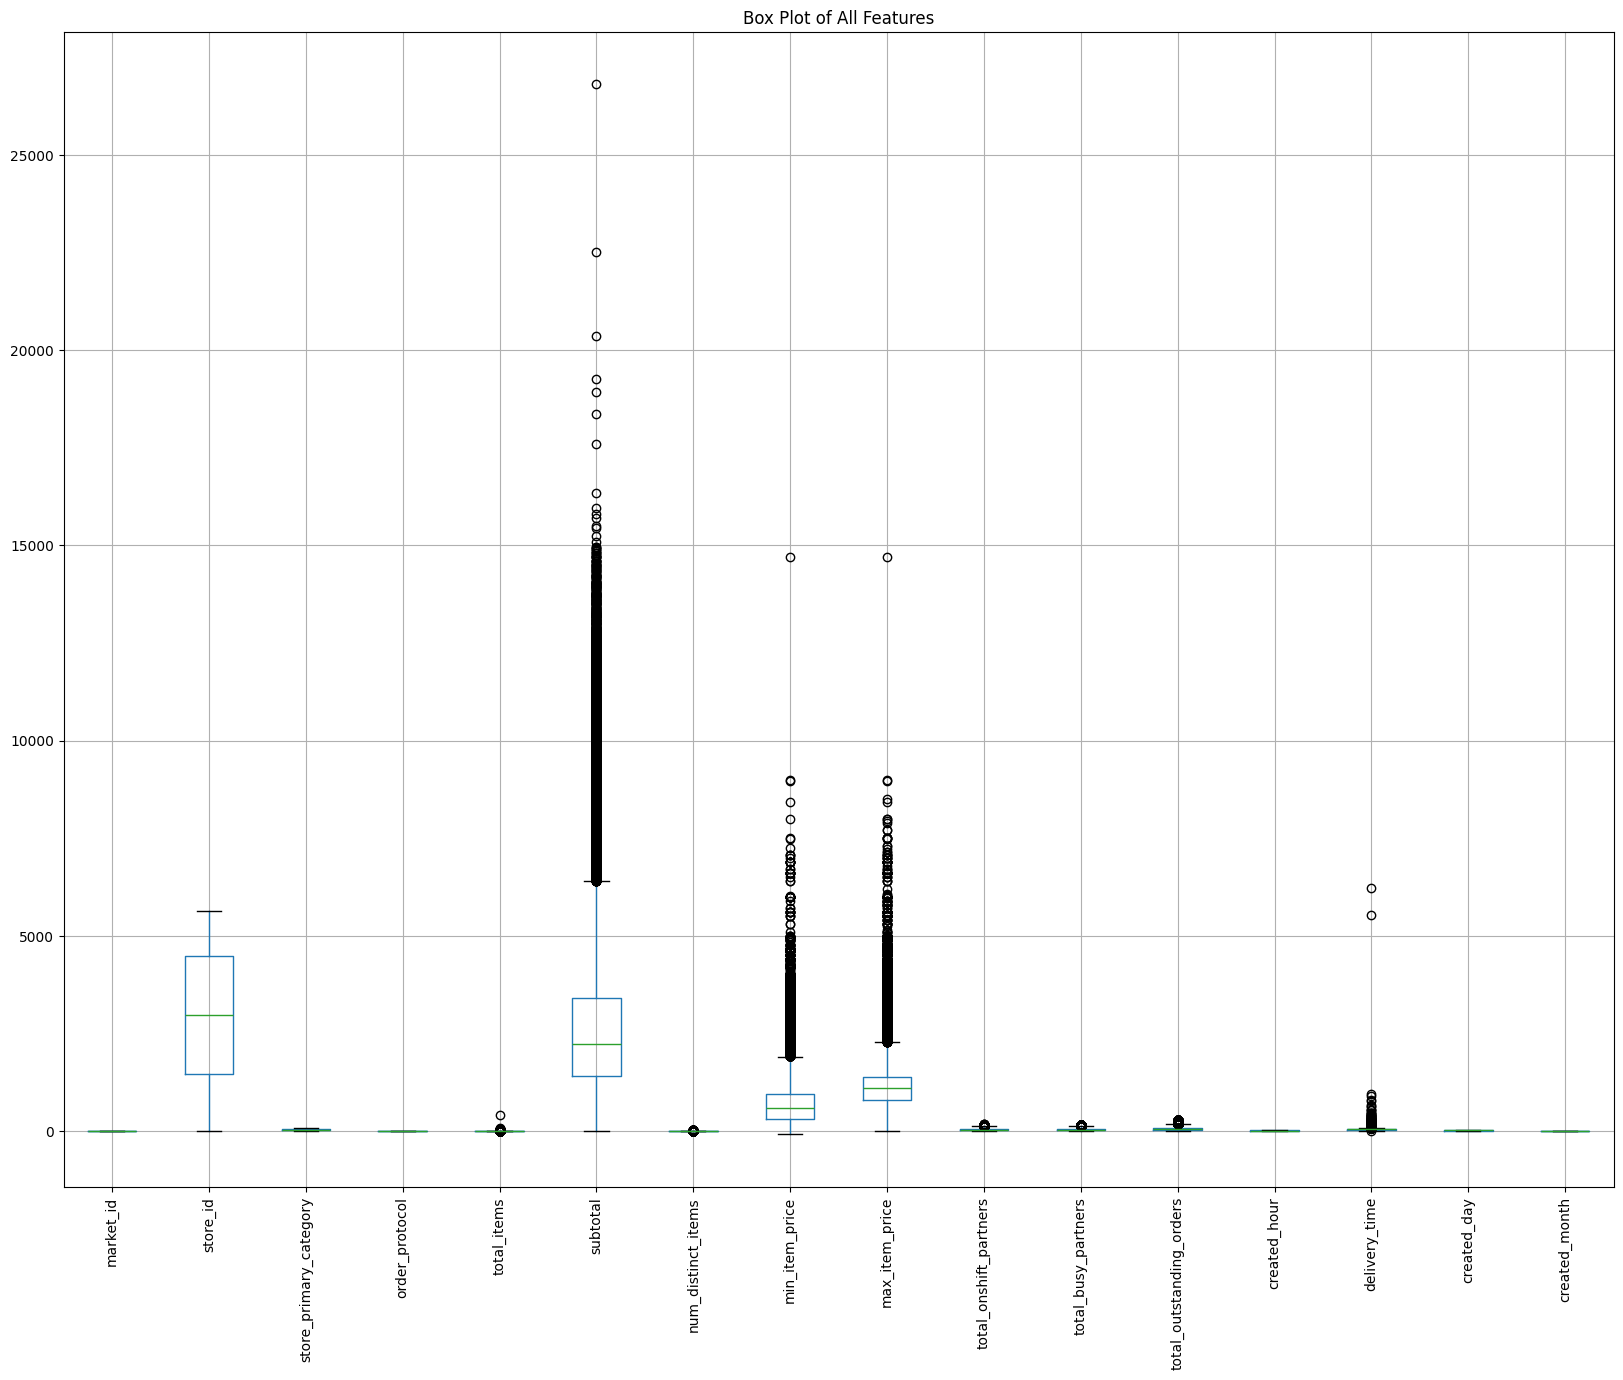

In [ ]:
plt.figure(figsize=(20, 15))
df.boxplot()
plt.xticks(rotation=90)
plt.title('Box Plot of All Features')
plt.show()

Based on the box plots, here are some inferences:

1. **market_id**: The distribution is relatively uniform with no significant outliers.
2. **store_id**: There are some outliers indicating that a few stores have significantly different values compared to the rest.
3. **store_primary_category**: The distribution is relatively uniform with no significant outliers.
4. **order_protocol**: There are some outliers indicating that a few order protocols have significantly different values compared to the rest.
5. **total_items**: There are some outliers indicating that a few orders have a significantly higher number of items.
6. **subtotal**: There are significant  outliers indicating that a few orders have a significantly higher subtotal.
7. **num_distinct_items**: There are some outliers indicating that a few orders have a significantly higher number of distinct items.
8. **min_item_price**: There are significant outliers indicating that a few items have a significantly lower minimum price.
9. **max_item_price**: There are significant outliers indicating that a few items have a significantly higher maximum price.
10. **total_onshift_partners**: There are some outliers indicating that the number of onshift partners varies significantly.
11. **total_busy_partners**: There are some outliers indicating that the number of busy partners varies significantly.
12. **total_outstanding_orders**: There are some outliers indicating that the number of outstanding orders varies significantly.
13. **created_hour**: The distribution is relatively uniform with no significant outliers.
14. **delivery_time**: There are some outliers indicating that a few deliveries took significantly longer.
15. **created_day**: The distribution is relatively uniform with no significant outliers.
16. **created_month**: The distribution is relatively uniform with no significant outliers.


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
model1=LocalOutlierFactor()
#model1.fit(df)
df['lof_anomaly_score']=model1.fit_predict(df)
df.lof_anomaly_score.value_counts()

,count
lof_anomaly_score,
1,175310
-1,938


In [ ]:
df.drop(df[df['lof_anomaly_score']==-1].index,inplace=True)

In [ ]:
df.shape

(175310, 17)

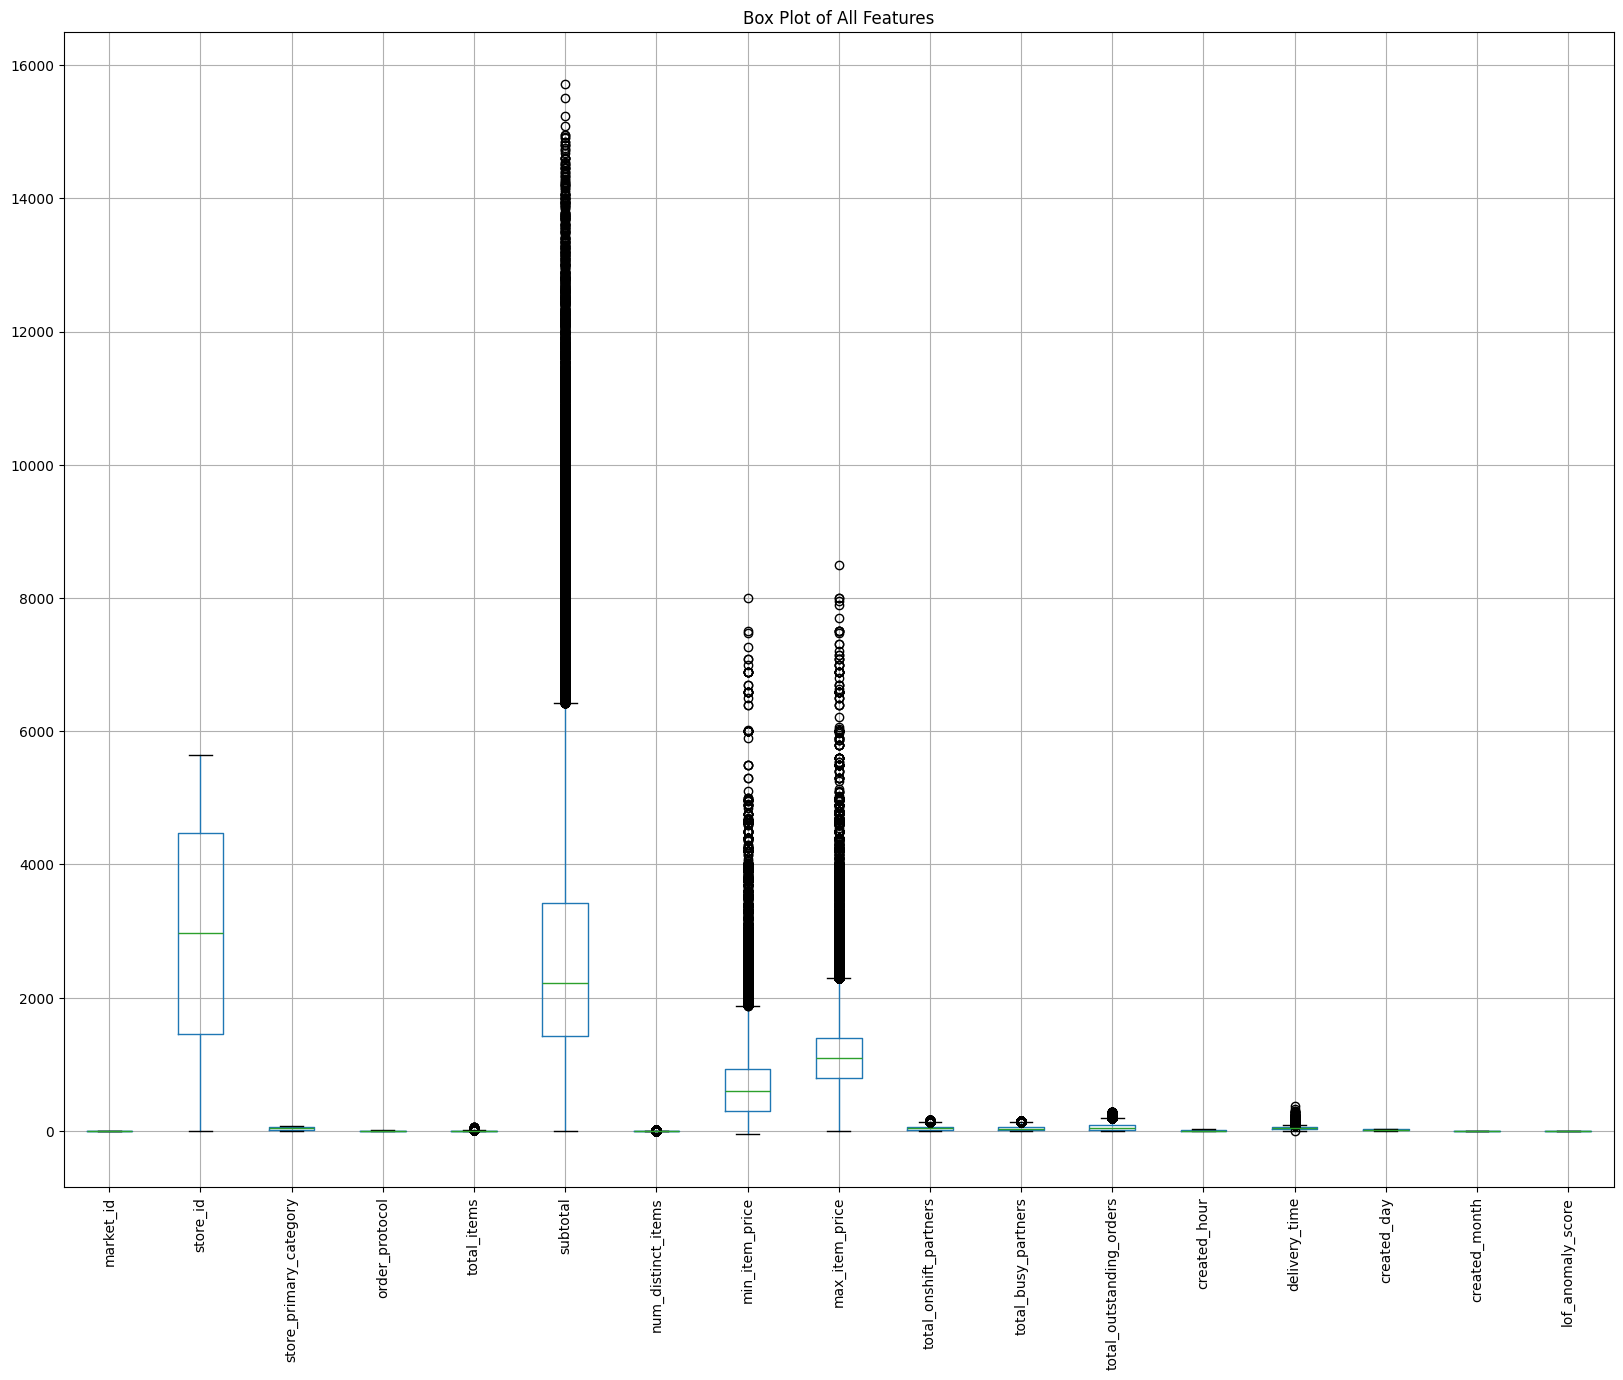

In [ ]:
plt.figure(figsize=(20, 15))
df.boxplot()
plt.xticks(rotation=90)
plt.title('Box Plot of All Features')
plt.show()

In [ ]:
# Outlier removal using Isolation Forest
from sklearn.ensemble import IsolationForest

In [ ]:
# Initialize the IsolationForest model
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# Fit the model and predict outliers
outliers = iso_forest.fit_predict(df)

# Add the outlier predictions to the dataframe
df['outliers'] = outliers

# Print the count of outliers
outlier_count = df['outliers'].value_counts()
print("Count of outliers:")
print(outlier_count)

# Filter out the outliers
df_cleaned = df[df['outliers'] == 1].drop(columns=['outliers'])

# Display the cleaned dataframe
df_cleaned.head()

# Calculate the number of outliers in each feature
outlier_features = df[df['outliers'] == -1].drop(columns=['outliers']).apply(lambda x: x.isin(df_cleaned).sum())
print("\nNumber of outliers in each feature:")
print(outlier_features)

Count of outliers:
outliers
 1    173556
-1      1754
Name: count, dtype: int64

Number of outliers in each feature:
market_id                   0
store_id                    0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
created_hour                0
delivery_time               0
created_day                 0
created_month               0
lof_anomaly_score           0
dtype: int64


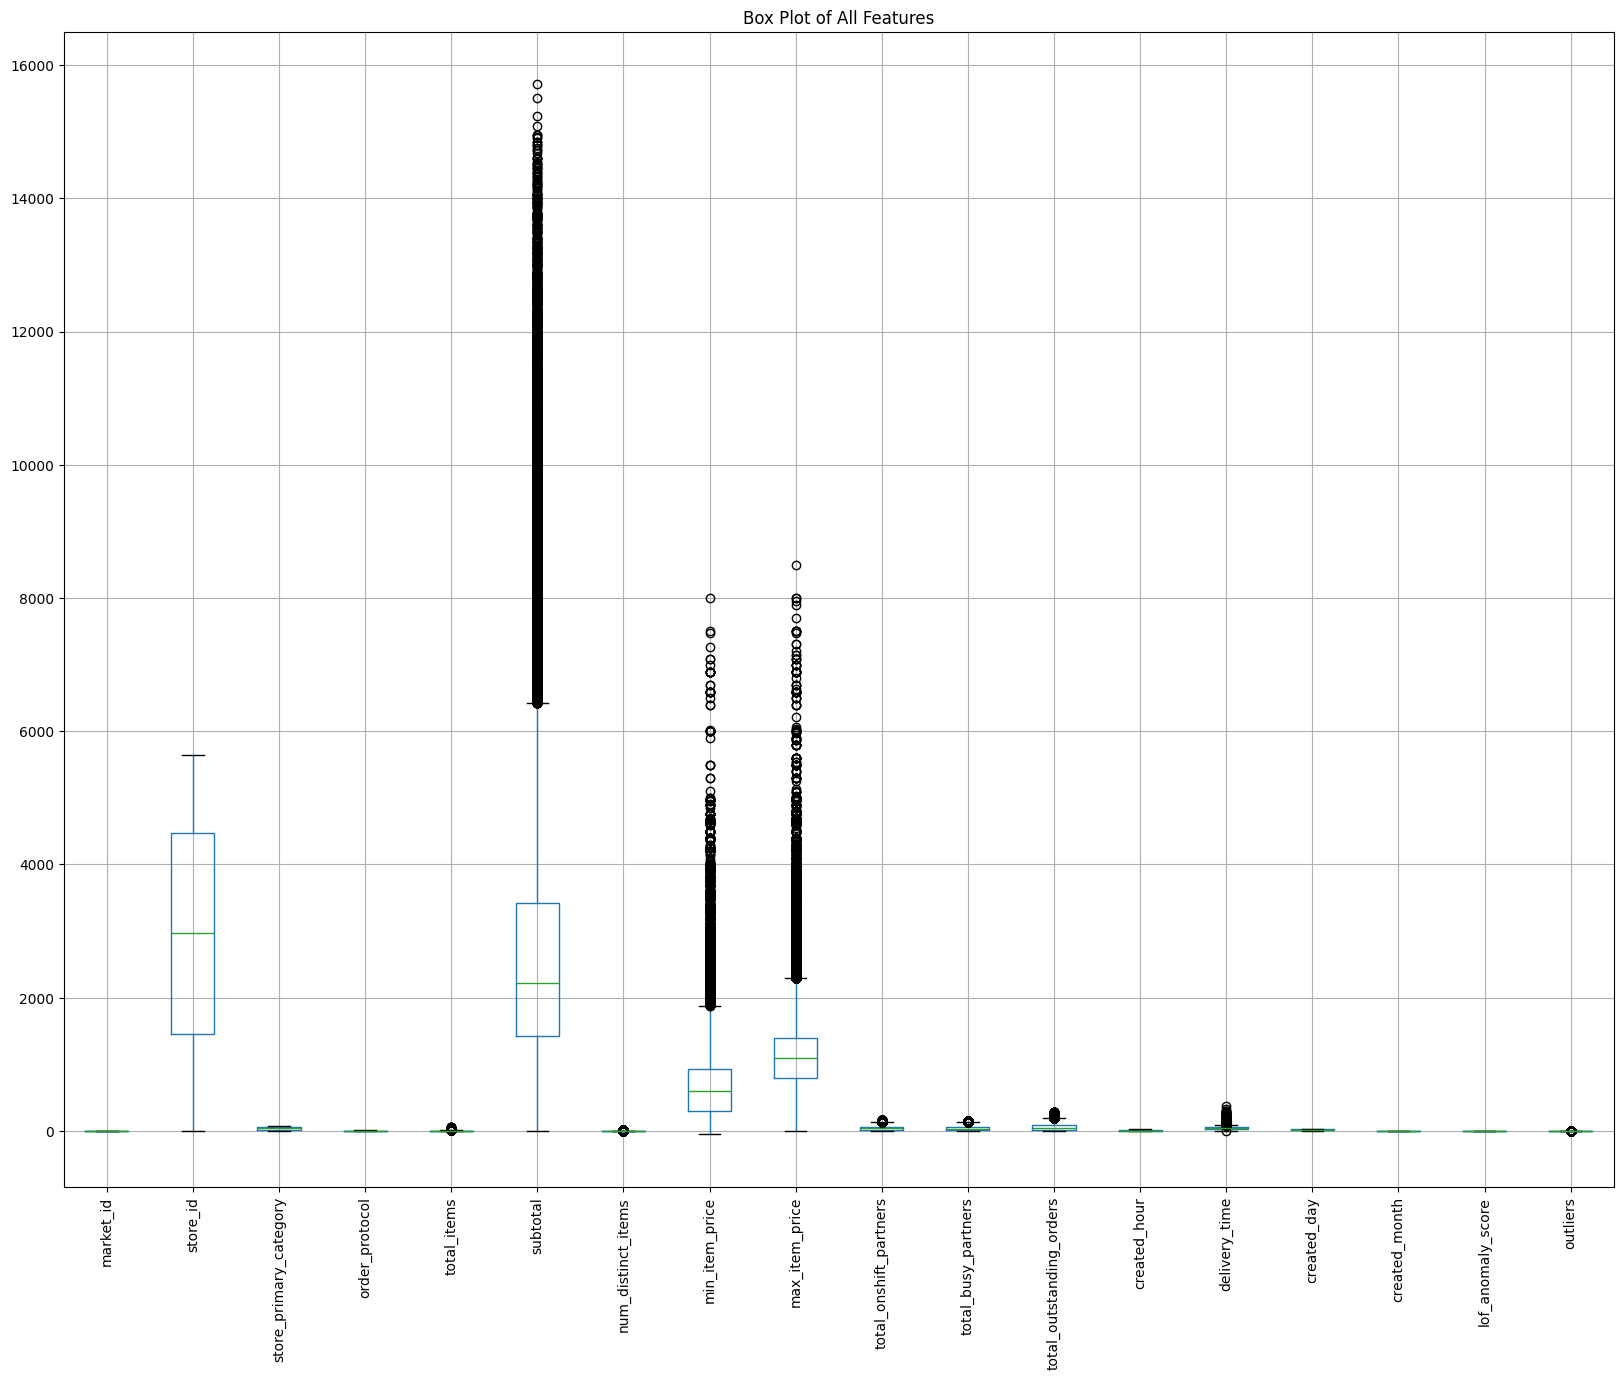

In [ ]:
plt.figure(figsize=(20, 15))
df.boxplot()
plt.xticks(rotation=90)
plt.title('Box Plot of All Features')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into train and test sets
train_data, test_data = train_test_split(df_cleaned, test_size=0.2, random_state=42)

# Further split the train data into train and validation sets
train_data, val_data = train_test_split(train_data, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

# Display the shapes of the datasets
print("Train data shape:", train_data.shape)
print("Validation data shape:", val_data.shape)
print("Test data shape:", test_data.shape)

Train data shape: (104133, 17)
Validation data shape: (34711, 17)
Test data shape: (34712, 17)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler

scaler = StandardScaler()

# Fit the scaler on the train data and transform the train, validation, and test data
train_data_scaled = scaler.fit_transform(train_data)
val_data_scaled = scaler.transform(val_data)
test_data_scaled = scaler.transform(test_data)

# Convert the scaled data back to DataFrames
train_data_scaled = pd.DataFrame(train_data_scaled, columns=train_data.columns)
val_data_scaled = pd.DataFrame(val_data_scaled, columns=val_data.columns)
test_data_scaled = pd.DataFrame(test_data_scaled, columns=test_data.columns)

# Display the scaled train data
train_data_scaled.head()

,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_hour,delivery_time,created_day,created_month,lof_anomaly_score
0,-1.310851,1.167167,-0.765991,1.379788,-0.496279,-0.231308,-0.417127,0.645095,0.183248,-1.304482,-1.306882,-1.110726,-0.860910,1.337094,-1.014016,0.734240,0.0
1,-0.559763,-1.441716,-1.537917,0.718223,-0.060073,-0.611137,0.236027,-0.360971,-1.024735,-1.071416,-1.087414,-0.957087,1.097911,1.011520,-0.037388,0.734240,0.0
2,0.191326,-1.242555,-0.380028,0.056657,-0.932484,-1.068566,-1.070282,0.272850,-0.623929,-1.071416,-1.212824,-1.072316,1.097911,-1.170381,1.047756,-1.361952,0.0
3,-0.559763,-0.958212,0.150671,1.379788,-0.060073,0.915181,0.236027,-0.411275,0.266749,0.589179,0.762388,0.233612,1.443585,-1.048291,-0.796988,0.734240,0.0
4,-0.559763,0.838432,-1.103709,0.718223,-0.060073,-0.494446,0.236027,-0.342862,-0.846599,1.026178,1.075914,0.694528,-0.515236,-0.921576,-0.471445,0.734240,0.0


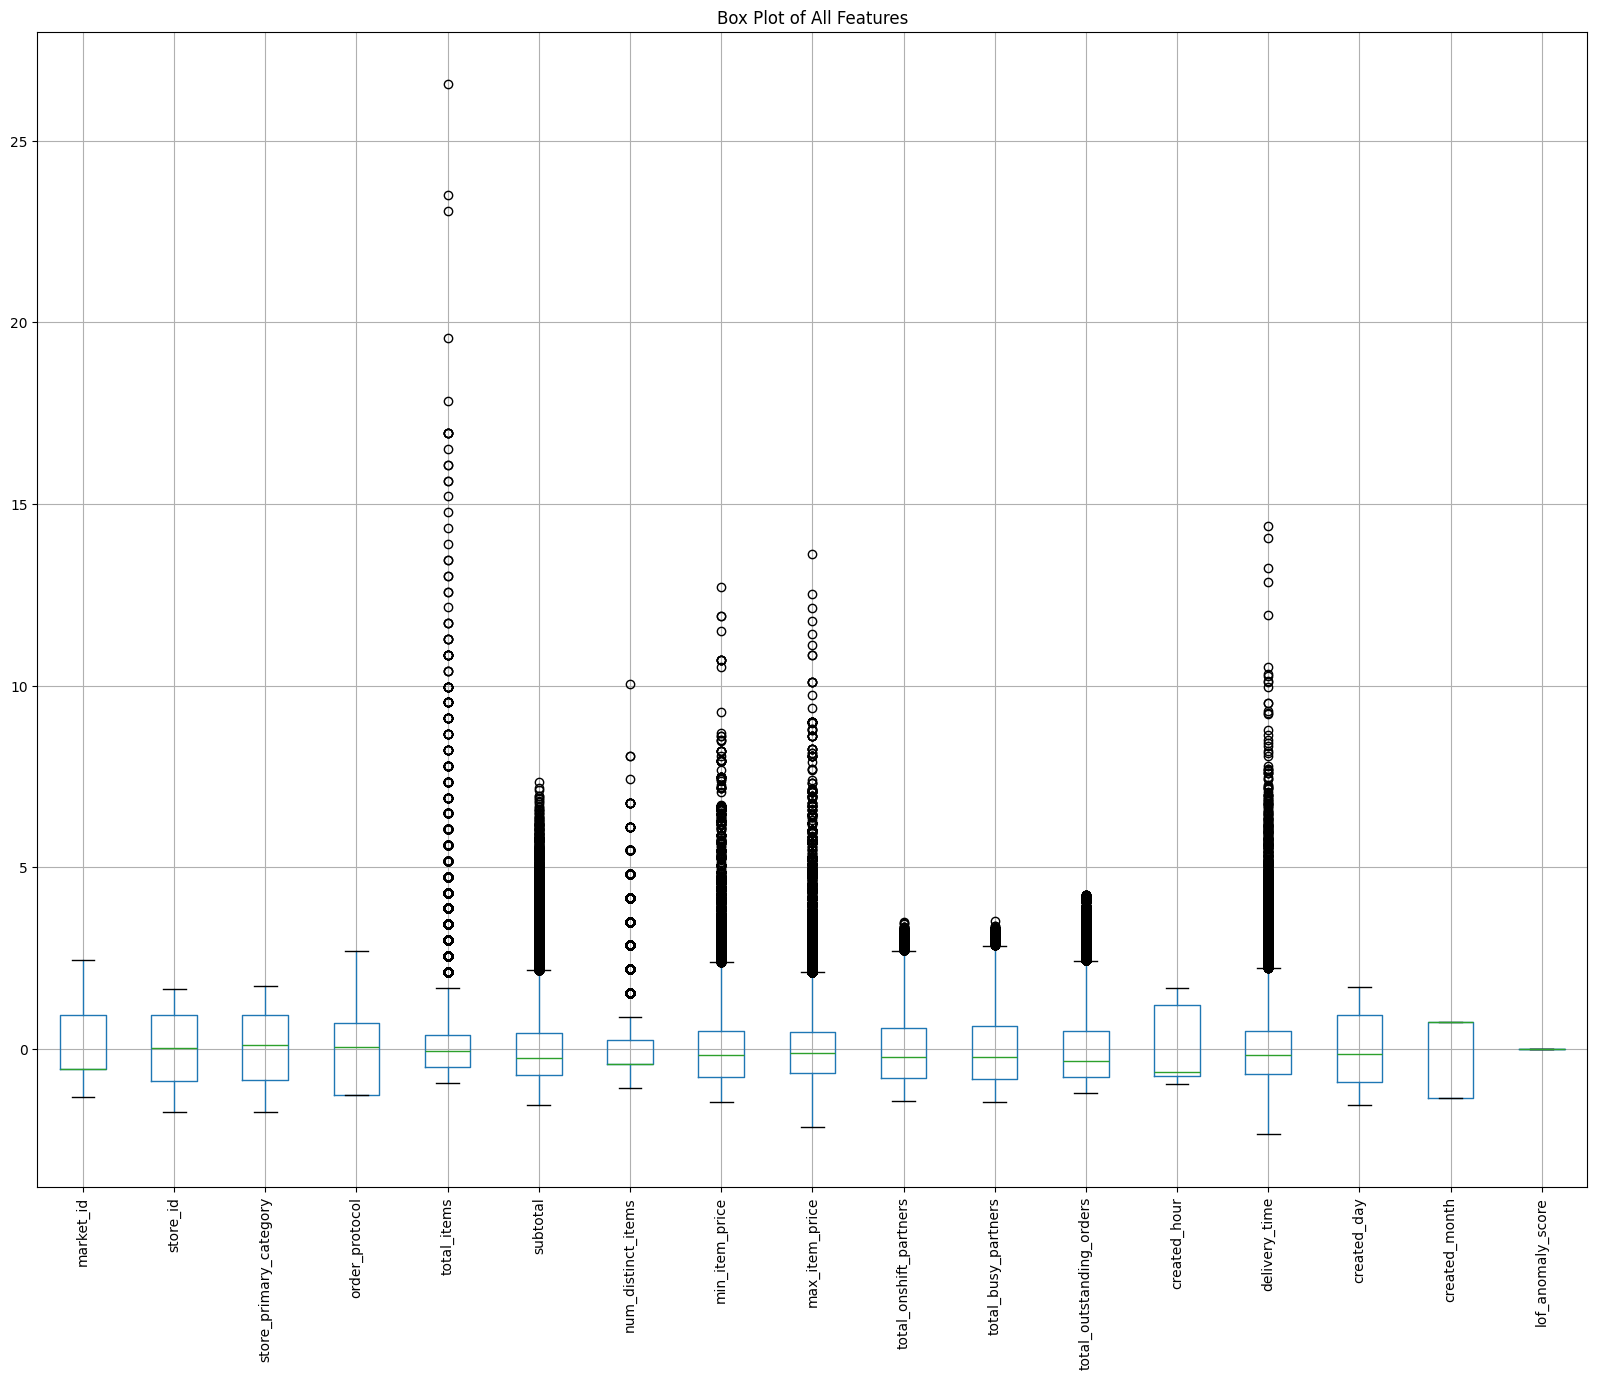

In [ ]:
plt.figure(figsize=(20, 15))
train_data_scaled.boxplot()
plt.xticks(rotation=90)
plt.title('Box Plot of All Features')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Separate features and target variable from the training data
X_train = train_data_scaled.drop(columns=['delivery_time'])
y_train = train_data_scaled['delivery_time']

# Separate features and target variable from the validation data
X_val = val_data_scaled.drop(columns=['delivery_time'])
y_val = val_data_scaled['delivery_time']

# Initialize the RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_regressor.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = rf_regressor.predict(X_val)

# Calculate the mean squared error
mse = mean_squared_error(y_val, y_val_pred)
print(f'Mean Squared Error on validation set: {mse}')



Mean Squared Error on validation set: 0.7320223445828108


In [ ]:
#Calculate the mean absolute error on validation set
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_val, y_val_pred)
print(f'Mean Absolute Error on validation set: {mae}')

#Calculate R2 Score on validation set
from sklearn.metrics import r2_score
r2 = r2_score(y_val, y_val_pred)
print(f'R2 Score on validation set: {r2}')

Mean Absolute Error on validation set: 0.6252981271306527
R2 Score on validation set: 0.27478163191151517


In [ ]:
#Print loss, mse, mae, r2score on both validation dataset and test dataset of RandomForestRegressor rounded to two decimalal places
print(f'Loss on validation set: {mse:.2f}')
print(f'MSE on validation set: {mse:.2f}')
print(f'MAE on validation set: {mae:.2f}')
print(f'R2 Score on validation set: {r2:.2f}')


Loss on validation set: 0.73
MSE on validation set: 0.73
MAE on validation set: 0.63
R2 Score on validation set: 0.27


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Separate features and target variable from the test data
X_test = test_data_scaled.drop(columns=['delivery_time'])
y_test = test_data_scaled['delivery_time']

# Predict on the test set
y_test_pred = rf_regressor.predict(X_test)

#Calculate the loss on test set
loss_test = mean_squared_error(y_test, y_test_pred)
print(f'Loss on test set: {loss_test:0.2f}')

# Calculate the mean squared error
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'Mean Squared Error on test set: {mse_test:0.2f}')

# Calculate the mean absolute error
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f'Mean Absolute Error on test set: {mae_test:0.2f}')

# Calculate the R^2 score
r2_test = r2_score(y_test, y_test_pred)
print(f'R^2 Score on test set: {r2_test:0.2f}')

Loss on test set: 0.73
Mean Squared Error on test set: 0.73
Mean Absolute Error on test set: 0.63
R^2 Score on test set: 0.29


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize the XGBRegressor
xgb_regressor = XGBRegressor(n_estimators=100, random_state=42)

# Train the model
xgb_regressor.fit(X_train, y_train)

# Predict on the validation set
y_val_pred_xgb = xgb_regressor.predict(X_val)

# Calculate validation metrics
mse_val_xgb = mean_squared_error(y_val, y_val_pred_xgb)
mae_val_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
r2_val_xgb = r2_score(y_val, y_val_pred_xgb)

print(f'Validation Mean Squared Error: {mse_val_xgb:0.2f}')
print(f'Validation Mean Absolute Error: {mae_val_xgb:0.2f}')
print(f'Validation R^2 Score: {r2_val_xgb:0.2f}')

# Predict on the test set
y_test_pred_xgb = xgb_regressor.predict(X_test)

# Calculate test metrics
mse_test_xgb = mean_squared_error(y_test, y_test_pred_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

print(f'Test Mean Squared Error: {mse_test_xgb:0.2f}')
print(f'Test Mean Absolute Error: {mae_test_xgb:0.2f}')
print(f'Test R^2 Score: {r2_test_xgb:0.2f}')

Validation Mean Squared Error: 0.69
Validation Mean Absolute Error: 0.60
Validation R^2 Score: 0.31
Test Mean Squared Error: 0.68
Test Mean Absolute Error: 0.60
Test R^2 Score: 0.33


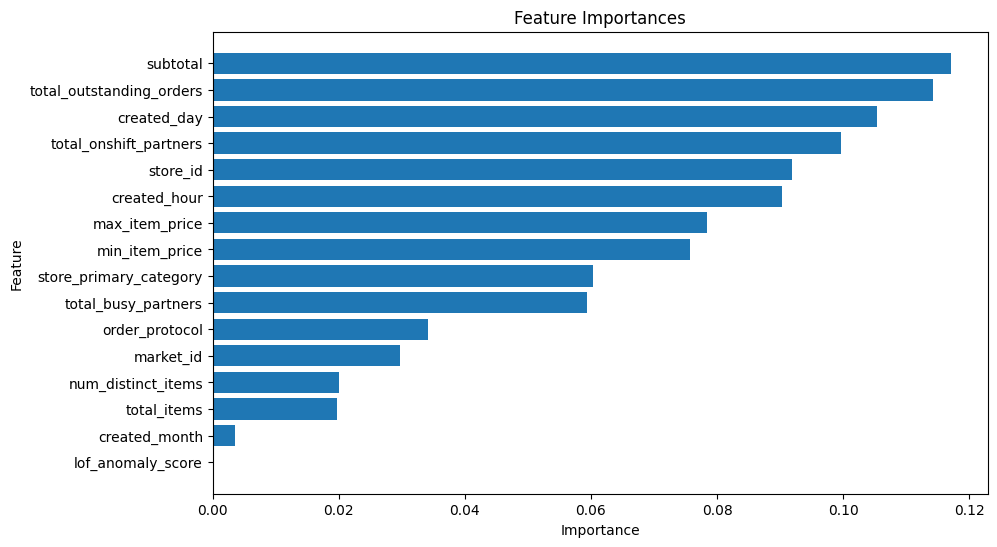

In [ ]:
# prompt: generate feature importance visual plot

import matplotlib.pyplot as plt

# Get feature importances from the trained RandomForestRegressor
feature_importances = rf_regressor.feature_importances_

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.show()


Here are the inferences from the Random Forest and XGBoost Regressor models:

### Random Forest Regressor:
1. **Mean Squared Error (MSE) on Validation Set**: The MSE on the validation set is `0.73`. This indicates the average squared difference between the predicted and actual delivery times.
2. **Mean Squared Error (MSE) on Test Set**: The MSE on the test set is `0.73`. This indicates the average squared difference between the predicted and actual delivery times on the test data.
3. **Mean Absolute Error (MAE) on Test Set**: The MAE on the test set is `0.63`. This indicates the average absolute difference between the predicted and actual delivery times on the test data.
4. **R^2 Score on Test Set**: The R^2 score on the test set is `0.27`. The low R² scores imply that the model is not capturing the underlying patterns effectively, leading to limited explanatory power. This might be due to insufficient features, noisy data, or a need for better hyperparameter tuning.

### XGBoost Regressor:

1. **Mean Squared Error (MSE) on Validation Set**: The MSE on the validation set is `0.69`. This indicates the average squared difference between the predicted and actual delivery times.
2. **Mean Squared Error (MSE) on Test Set**: The MSE on the test set is `0.68`. This indicates the average squared difference between the predicted and actual delivery times on the test data.
3. **Mean Absolute Error (MAE) on Test Set**: The MAE on the test set is `0.60`. This indicates the average absolute difference between the predicted and actual delivery times on the test data.
4. **R^2 Score on Test Set**: The R^2 score on the test set is `0.33`. The low R² scores imply that the model is not capturing the underlying patterns effectively, leading to limited explanatory power. This might be due to insufficient features, noisy data, or a need for better hyperparameter tuning.

### Summary:
- The XGBoost Regressor outperforms the Random Forest Regressor in terms of MSE, MAE, and R^2 score on the test set.
- The XGBoost Regressor has a lower MSE and MAE, indicating more accurate predictions.

These inferences suggest that the XGBoost Regressor is a better model for predicting delivery times in this dataset.

In [ ]:
print('Train : ', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test  : ', X_test.shape, y_test.shape)

Train :  (104133, 16) (104133,)
Validation: (34711, 16) (34711,)
Test  :  (34712, 16) (34712,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout


# For Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1], )))

model.add(Dense(16, kernel_initializer="normal", activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(512, activation='relu'))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='linear'))

In [ ]:
import os

# Create a function to implement a ModelCheckpoint callback with a specific filename
def create_model_checkpoint(model_name, save_path="model_experiments"):
  return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(save_path, model_name), # create filepath to save model
                                            verbose=0, # only output a limited amount of text
                                            save_best_only=True) # save only the best model to file

In [ ]:
from keras.src.optimizers import Adam
adam=Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer=adam,metrics=['mse','mae'])
history=model.fit(X_train,y_train,epochs=10,batch_size=512,verbose=1, validation_split=0.2 ,callbacks=[create_model_checkpoint(model_name="model_1.keras")])

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9034 - mae: 0.7000 - mse: 0.9034 - val_loss: 0.8114 - val_mae: 0.6658 - val_mse: 0.8114
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.8226 - mae: 0.6659 - mse: 0.8226 - val_loss: 0.8059 - val_mae: 0.6664 - val_mse: 0.8059
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.8132 - mae: 0.6623 - mse: 0.8132 - val_loss: 0.7984 - val_mae: 0.6621 - val_mse: 0.7984
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.8078 - mae: 0.6587 - mse: 0.8078 - val_loss: 0.7984 - val_mae: 0.6615 - val_mse: 0.7984
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.8050 - mae: 0.6579 - mse: 0.8050 - val_loss: 0.7971 - val_mae: 0.6532 - val_mse: 0.7971
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.8019 - mae: 0.6562 - mse: 0.8019 - val_loss: 0.7941 - val_mae: 0.6592 - val_mse: 0.7941
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.8010 - mae: 0.6568 - mse: 0.801

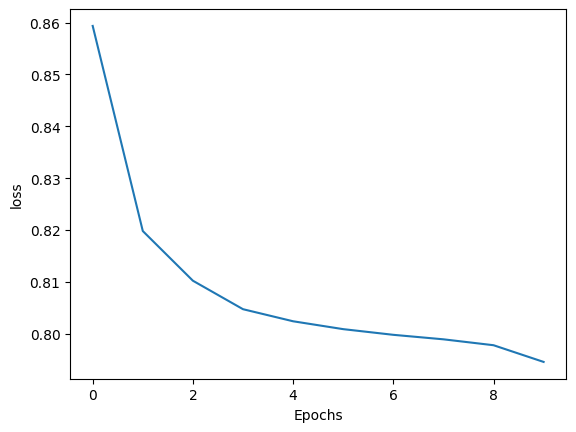

In [ ]:
def plot_history(history,key):
    plt.plot(history.history[key])
    plt.xlabel("Epochs")
    plt.ylabel(key)
    plt.show()
#plot the history
plot_history(history,'loss')

In [ ]:
def metrics_evals(y_true,y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {"MSE":mse,
            "RMSE":rmse,
            "MAE":mae,
            "R2":r2}

In [ ]:
prediction = model.predict(X_test)
eval = metrics_evals(y_test, prediction)
eval

1085/1085 ━━━━━━━━━━━━━━━━━━━━ 1s 996us/step


{'MSE': 0.7960977173961009,
 'RMSE': 0.7960977173961009,
 'MAE': 0.6538172438741756,
 'R2': 0.2201293688481767}

In [ ]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1], )))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(256, activation='relu'))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='linear'))

In [ ]:
adam=Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer=adam,metrics=['mse','mae'])
history=model.fit(X_train,y_train,epochs=20,batch_size=512,verbose=1 ,callbacks=[create_model_checkpoint(model_name="model_2.keras")])

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.9529 - mae: 0.7200 - mse: 0.9529
Epoch 2/20


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.8124 - mae: 0.6592 - mse: 0.8124
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.8062 - mae: 0.6558 - mse: 0.8062
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.8001 - mae: 0.6540 - mse: 0.8001
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.7986 - mae: 0.6527 - mse: 0.7986
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.7971 - mae: 0.6522 - mse: 0.7971
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.7951 - mae: 0.6511 - mse: 0.7951
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.7945 - mae: 0.6517 - mse: 0.7945
Epoch 9/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.7914 - mae: 0.6490 - mse: 0.7914
Epoch 10/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.7938 - mae: 0.6507 - mse: 0.7938
Epoch 11/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.7934 - mae: 0.6505 - mse: 0.7934
Epoch 12/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential()
model.add(Input(shape=(X_train.shape[1], )))

# 1st Hidden Layer
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# 2nd Hidden Layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# 3rd Hidden Layer
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# 4th Hidden Layer (optional for complexity)
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='linear'))

# Optimizer
adam = Adam(learning_rate=0.001)

# Compile the model
model.compile(loss='mse', optimizer=adam, metrics=['mse', 'mae'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train the model with explicit validation data
history = model.fit(X_train, y_train,
                    epochs=50,  # Increased epochs for better convergence
                    batch_size=256,  # Reduced batch size for better generalization
                    validation_data=(X_val, y_val),  # Explicit validation set
                    verbose=1,
                    callbacks=[early_stop, reduce_lr, create_model_checkpoint(model_name="optimized_model.keras")])


Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 2.0107 - mae: 1.0535 - mse: 2.0107 - val_loss: 0.8979 - val_mae: 0.6807 - val_mse: 0.8979 - learning_rate: 0.0010
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.9876 - mae: 0.7369 - mse: 0.9876 - val_loss: 0.8335 - val_mae: 0.6564 - val_mse: 0.8335 - learning_rate: 0.0010
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.8623 - mae: 0.6823 - mse: 0.8623 - val_loss: 0.8024 - val_mae: 0.6458 - val_mse: 0.8024 - learning_rate: 0.0010
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.8287 - mae: 0.6666 - mse: 0.8287 - val_loss: 0.7916 - val_mae: 0.6428 - val_mse: 0.7916 - learning_rate: 0.0010
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.8135 - mae: 0.6602 - mse: 0.8135 - val_loss: 0.7867 - val_mae: 0.6395 - val_mse: 0.7867 - learning_rate: 0.0010
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.8038 - mae: 0.6546 - mse: 0.8038 - val_loss: 0.7842 - val_mae: 0.637

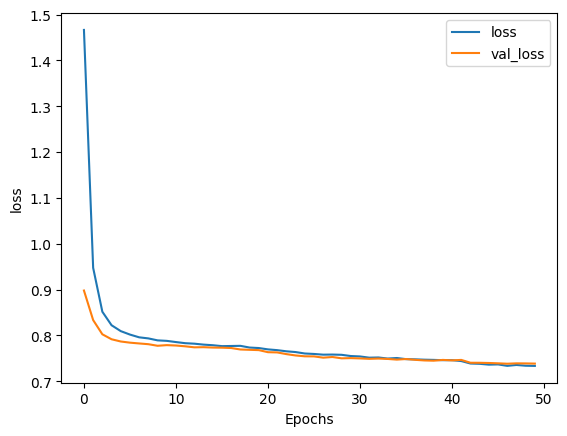

In [ ]:
def plot_history(history, key):
  plt.plot(history.history[key])
  plt.plot(history.history['val_'+key])
  plt.xlabel("Epochs")
  plt.ylabel(key)
  plt.legend([key, 'val_'+key])
  plt.show()
# Plot the history
plot_history(history, 'loss')

In [ ]:
prediction = model.predict(X_test)
eval = metrics_evals(y_test, prediction)
eval

1085/1085 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


{'MSE': 0.7370713780760679,
 'RMSE': 0.7370713780760679,
 'MAE': 0.6221117988873328,
 'R2': 0.2779525575022801}

In [ ]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1], )))

# 1st Hidden Layer
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# 2nd Hidden Layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# 3rd Hidden Layer
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# 4th Hidden Layer (optional for complexity)
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# 5th Hidden Layer (optional for complexity)
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='linear'))

# Optimizer
adam = Adam(learning_rate=0.001)

# Compile the model
model.compile(loss='mse', optimizer=adam, metrics=['mse', 'mae'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train the model with explicit validation data
history = model.fit(X_train, y_train,
                    epochs=50,  # Increased epochs for better convergence
                    batch_size=256,  # Reduced batch size for better generalization
                    validation_data=(X_val, y_val),  # Explicit validation set
                    verbose=1,
                    callbacks=[early_stop, reduce_lr, create_model_checkpoint(model_name="optimized_model.keras")])


Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.6470 - mae: 0.9498 - mse: 1.6470 - val_loss: 0.8888 - val_mae: 0.6812 - val_mse: 0.8888 - learning_rate: 0.0010
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.9470 - mae: 0.7187 - mse: 0.9470 - val_loss: 0.8288 - val_mae: 0.6587 - val_mse: 0.8288 - learning_rate: 0.0010
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.8638 - mae: 0.6827 - mse: 0.8638 - val_loss: 0.8035 - val_mae: 0.6497 - val_mse: 0.8035 - learning_rate: 0.0010
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.8309 - mae: 0.6672 - mse: 0.8309 - val_loss: 0.7933 - val_mae: 0.6435 - val_mse: 0.7933 - learning_rate: 0.0010
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.8181 - mae: 0.6613 - mse: 0.8181 - val_loss: 0.7888 - val_mae: 0.6409 - val_mse: 0.7888 - learning_rate: 0.0010
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.8055 - mae: 0.6566 - mse: 0.8055 - val_loss: 0.7840 - val_mae: 0.639

In [ ]:
prediction = model.predict(X_test)
eval = metrics_evals(y_test, prediction)
eval

1085/1085 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


{'MSE': 0.7389896830700415,
 'RMSE': 0.7389896830700415,
 'MAE': 0.6235563551791883,
 'R2': 0.2760733538647101}

In [ ]:
df.shape

(175310, 18)

In [ ]:
X_train.shape

(104133, 16)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the model
model = Sequential()
model.add(Input(shape=(X_train.shape[1], )))

# 1st Hidden Layer
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# 2nd Hidden Layer
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='linear'))

# Optimizer
adam = Adam(learning_rate=0.001)

# Compile the model
model.compile(loss='mse', optimizer=adam, metrics=['mse', 'mae'])

# Callbacks for early stopping and learning rate reduction
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=256,
                    validation_data=(X_val, y_val),
                    verbose=1,
                    callbacks=[early_stop, reduce_lr, create_model_checkpoint(model_name="simple_nn_model.keras")])


Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.1990 - mae: 1.1025 - mse: 2.1990 - val_loss: 0.8911 - val_mae: 0.6935 - val_mse: 0.8911 - learning_rate: 0.0010
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.0019 - mae: 0.7454 - mse: 1.0019 - val_loss: 0.8552 - val_mae: 0.6711 - val_mse: 0.8552 - learning_rate: 0.0010
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8826 - mae: 0.6919 - mse: 0.8826 - val_loss: 0.8206 - val_mae: 0.6601 - val_mse: 0.8206 - learning_rate: 0.0010
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8388 - mae: 0.6716 - mse: 0.8388 - val_loss: 0.8056 - val_mae: 0.6513 - val_mse: 0.8056 - learning_rate: 0.0010
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8227 - mae: 0.6635 - mse: 0.8227 - val_loss: 0.7964 - val_mae: 0.6465 - val_mse: 0.7964 - learning_rate: 0.0010
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8136 - mae: 0.6602 - mse: 0.8136 - val_loss: 0.7920 - val_mae: 0.645

In [ ]:
prediction = model.predict(X_test)
eval = metrics_evals(y_test, prediction)
eval

1085/1085 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


{'MSE': 0.7527015519834265,
 'RMSE': 0.7527015519834265,
 'MAE': 0.6316826852692752,
 'R2': 0.26264097787608254}

In [ ]:
from tensorflow.keras.regularizers import l2

model = Sequential()
model.add(Input(shape=(X_train.shape[1], )))

# 1st Hidden Layer with L2 Regularization
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Feature Interaction Layer
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())

# 2nd Hidden Layer
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='linear'))

# Compile the model
adam = Adam(learning_rate=0.0005)
model.compile(loss='mse', optimizer=adam, metrics=['mse', 'mae'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=256,
                    validation_data=(X_val, y_val),
                    verbose=1,
                    callbacks=[early_stop, reduce_lr, create_model_checkpoint(model_name="improved_nn_model.keras")])


Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.7994 - mae: 1.0103 - mse: 1.7528 - val_loss: 0.9745 - val_mae: 0.7097 - val_mse: 0.9296 - learning_rate: 5.0000e-04
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1346 - mae: 0.7796 - mse: 1.0900 - val_loss: 0.9365 - val_mae: 0.6928 - val_mse: 0.8930 - learning_rate: 5.0000e-04
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.0092 - mae: 0.7279 - mse: 0.9662 - val_loss: 0.9113 - val_mae: 0.6803 - val_mse: 0.8695 - learning_rate: 5.0000e-04
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9443 - mae: 0.7009 - mse: 0.9029 - val_loss: 0.8846 - val_mae: 0.6680 - val_mse: 0.8446 - learning_rate: 5.0000e-04
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9008 - mae: 0.6816 - mse: 0.8613 - val_loss: 0.8599 - val_mae: 0.6571 - val_mse: 0.8219 - learning_rate: 5.0000e-04
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8735 - mae: 0.6699 - mse: 0.8360 - val_loss: 0.8

In [ ]:
prediction = model.predict(X_test)
eval = metrics_evals(y_test, prediction)
eval

1085/1085 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


{'MSE': 0.7534679314396665,
 'RMSE': 0.7534679314396665,
 'MAE': 0.6322455275729805,
 'R2': 0.26189021975031557}

1. Defining the problem statements and where can this and modifications of this be used?
- Delivery time estimation for the orders, we can use this case with some modification in the **Estimate Cab Arrival Time**.

2. List 3 functions the pandas datetime provides with one line explanation.
- pd.to_datetime(): Converts a date string or a numeric timestamp into a pandas Datetime object.

- .dt accessor: Allows vectorized access to attributes like year, month, day, hour, etc., from a Datetime column in a pandas DataFrame.

- pd.date_range(): Generates a sequence of Datetime objects at specified frequency, such as daily, monthly, or hourly intervals.

3. Short note on datetime, timedelta, time span (period)
- Datetime
    - A datetime represents a specific point in time, including both the date and the time of day.

- Timedelta
    - A timedelta represents the difference between two datetime objects, typically expressed in days, seconds, and microseconds.

- Time Span (Period)
    - A Period represents a time span or interval of time, such as a specific month, quarter, or year.
4. Why do we need to check for outliers in our data?
- Checking for outliers is a critical step in data preprocessing that helps ensure the reliability of statistical analysis, improves model performance, maintains data quality, and sometimes uncovers important insights.

5. Name 3 outlier removal methods?
- Z-Score Method
- IQR Method
- LOF Method

6. What classical machine learning methods can we use for this problem?
- Random Forest
- XGBoost
- Linear Regression

7. Why is scaling required for neural networks?
- Convergence Speed
- Numerical Stability
- Improving weight initialization

8. Briefly explain your choice of optimizer.
- We are using ADAM because of the following reason
  - Moment Estimation: Computes estimates of the first moment (mean) and second moment (uncentered variance) of the gradients.
  - Bias Correction: Applies bias correction to the moment estimates to counteract their initialization bias.
  - Parameter Update: Updates parameters using these corrected moment estimates, adjusted by learning rates.

9. Which activation function did you use and why?
- We are using RELU because of the following reasons:
  - Mitigating vanishing gradients
  - Sparse Activation
  - Avoid exploding gradients

10. Why does a neural network perform well on a large dataset?
- Neural networks perform well on large datasets because they provide diverse, representative, and sufficient data that helps in learning complex patterns, reducing overfitting, and improving generalization. The increased volume of data supports the training of more sophisticated models and enhances their ability to make accurate predictions.